In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [6]:
(x_train, y_train), (x_test,y_test) = datasets.cifar10.load_data()
x_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 69s 0us/step


(50000, 32, 32, 3)

In [7]:
x_train.shape

(50000, 32, 32, 3)

In [8]:
x_test.shape

(10000, 32, 32, 3)

In [9]:
y_train.shape

(50000, 1)

In [10]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [11]:
y_train = y_train.reshape(-1,)   #2D array can be reshaped into 1D array using reshape(-1)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [12]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [13]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [14]:
def plot_sample(x, y, index):
    plt.figure(figsize = (20,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])


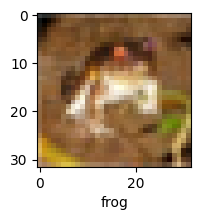

In [15]:
plot_sample(x_train, y_train, 0)

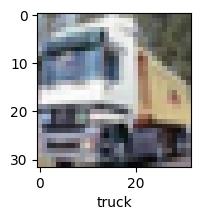

In [16]:
plot_sample(x_train,y_train,1)

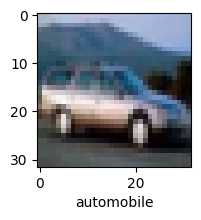

In [17]:
plot_sample(x_train,y_train,4)

In [18]:
x_train=x_train/255.0
x_test=x_test/255.0

In [19]:
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [20]:
annmodel = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(1000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
annmodel.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
annmodel.fit(x_train,y_train,epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.3433 - loss: 1.8365
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.4172 - loss: 1.6502
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.4451 - loss: 1.5683
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4674 - loss: 1.5098
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.4844 - loss: 1.4609


In [23]:
cnnmodel = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
cnnmodel.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [25]:
history=cnnmodel.fit(x_train, y_train,validation_data=(x_test,y_test),epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - accuracy: 0.4734 - loss: 1.4660 - val_accuracy: 0.5752 - val_loss: 1.2021
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.6091 - loss: 1.1172 - val_accuracy: 0.6349 - val_loss: 1.0608
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6542 - loss: 0.9917 - val_accuracy: 0.6570 - val_loss: 0.9882
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6869 - loss: 0.9080 - val_accuracy: 0.6725 - val_loss: 0.9567
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.7046 - loss: 0.8465 - val_accuracy: 0.6707 - val_loss: 0.9503
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.7232 - loss: 0.7912 - val_accuracy: 0.6981 - val_loss: 0.8932
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.7421 - loss: 0.7422 - val_accuracy: 0.6912 - val_loss: 0.9079
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7572 -

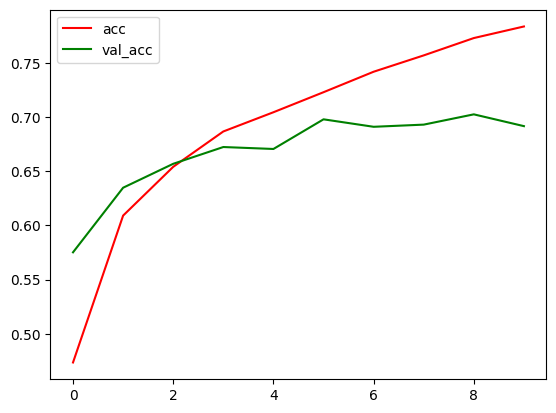

In [26]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='acc', color='red')
plt.plot(history.history['val_accuracy'],label='val_acc', color='green')
plt.legend()

In [29]:
y_pred = cnnmodel.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


array([[3.72024442e-05, 4.02432372e-04, 9.07150097e-03, 6.91486835e-01,
        7.33225315e-04, 2.91937262e-01, 5.30544249e-03, 1.00113597e-04,
        8.19042500e-04, 1.06952590e-04],
       [2.97792540e-05, 6.94780902e-04, 6.69914044e-08, 1.07032907e-08,
        5.44432366e-09, 1.10388634e-11, 9.37824374e-10, 2.03053419e-09,
        9.99258280e-01, 1.71386473e-05],
       [3.00453216e-01, 1.01463564e-01, 1.93030643e-03, 2.19196896e-03,
        1.30981917e-03, 3.24879540e-04, 4.30405978e-03, 8.70946050e-03,
        5.12050629e-01, 6.72620460e-02],
       [5.13216197e-01, 2.88177026e-03, 2.08852477e-02, 1.07578526e-03,
        1.36181145e-04, 2.98311552e-05, 1.23242137e-03, 8.39994482e-06,
        4.60479021e-01, 5.51246267e-05],
       [2.01269595e-05, 4.20398374e-06, 1.55913029e-02, 1.89999137e-02,
        5.24232388e-01, 8.56176484e-03, 4.32539165e-01, 1.96891451e-05,
        3.10894611e-05, 4.12457211e-07]], dtype=float32)

In [30]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [31]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

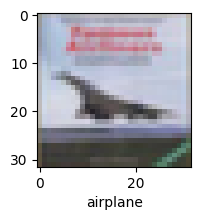

In [32]:
plot_sample(x_test, y_test,3)

In [33]:
classes[y_classes[3]]

'airplane'

In [34]:
cnnmodel.save('cnnmodel.h5')